##### Intro to Python Programming
- Prof Joanna Bieri
- Office: Duke 209

### Day 18 - Some Web Scraping and Pandas Data Analysis


Go to the following webpage and consider the information:

https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/global/time-series


If you are following the ethical principles of web scraping, should you scrape this data? Here is a reminder of the rules:

The Ethical Scraper (from https://towardsdatascience.com/ethics-in-web-scraping-b96b18136f01):

I, the web scraper will live by the following principles:

- If you have a public API that provides the data I’m looking for, I’ll use it and avoid scraping all together.
- I will always provide a User Agent string that makes my intentions clear and provides a way for you to contact me with questions or concerns.
- I will request data at a reasonable rate. I will strive to never be confused for a DDoS attack.
- I will only save the data I absolutely need from your page. If all I need it OpenGraph meta-data, that’s all I’ll keep.
- I will respect any content I do keep. I’ll never pass it off as my own.
- I will look for ways to return value to you. Maybe I can drive some (real) traffic to your site or credit you in an article or post.
- I will respond in a timely fashion to your outreach and work with you towards a resolution.
- I will scrape for the purpose of creating new value from the data, not to duplicate it.

### Your answer here:

# no, there are already like csv's anf other resourses to download it. scraping eould maybe take additional data thats either irrelivent or not intended for the public

#### See my answer/discussion below.

### Should you scrape this data?

# NO

Why not? Because the data is already available through the API (application programming interface). Basically on the webiste there is the option to download the data. So you should use that option.

#### Download the data and drop it into your working directory. On google colab this will mean dropping the data into the runtime folder (which will be deleted when your session ends).



In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
# Use pandas to load the data and look at the top entries:
DF = pd.read_csv('data.csv',skiprows=4)
DF

,1850,-0.13
0,1851,-0.08
1,1852,-0.21
2,1853,-0.19
3,1854,-0.09
4,1855,-0.07
...,...,...
171,2022,0.90
172,2023,1.01
173,2024,1.40
174,2025,1.22


In [7]:
DF.keys()

Index(['1850', '-0.13'], dtype='object')

### Practice 1

Open up the data file that you downloaded and put in your working directory. Can you figure out why I added the command skiprows=4? What happens if you remove that command?

there is an error

### Practice 2

Look back at your code from when we made bar plots for the Disney movies. It should look something like this:

    # Get the top 20 movies
    Disney_DF_top20 = Disney_DF.sort_values('inflation_adjusted_gross',ascending=False).iloc[:20]
    
    # Make a plot
    # Choose the size of the plot
    plt.figure(figsize=(16,8))
    
    # Name the plot
    plt.title('Disney Top 20 Movies')
    
    # Get the values
    x_values = Disney_DF_top20['movie_title']
    y_values = Disney_DF_top20['inflation_adjusted_gross']
    
    # Create the bar plot with the values
    plt.bar(x_values,y_values)
    # Rotate the names so you can read them
    plt.xticks(rotation=90)
    # Add grid lines if you want them
    plt.grid()

    # Show the plot
    plt.show()
    
#### Write code that recreates the plot that you see on the website.

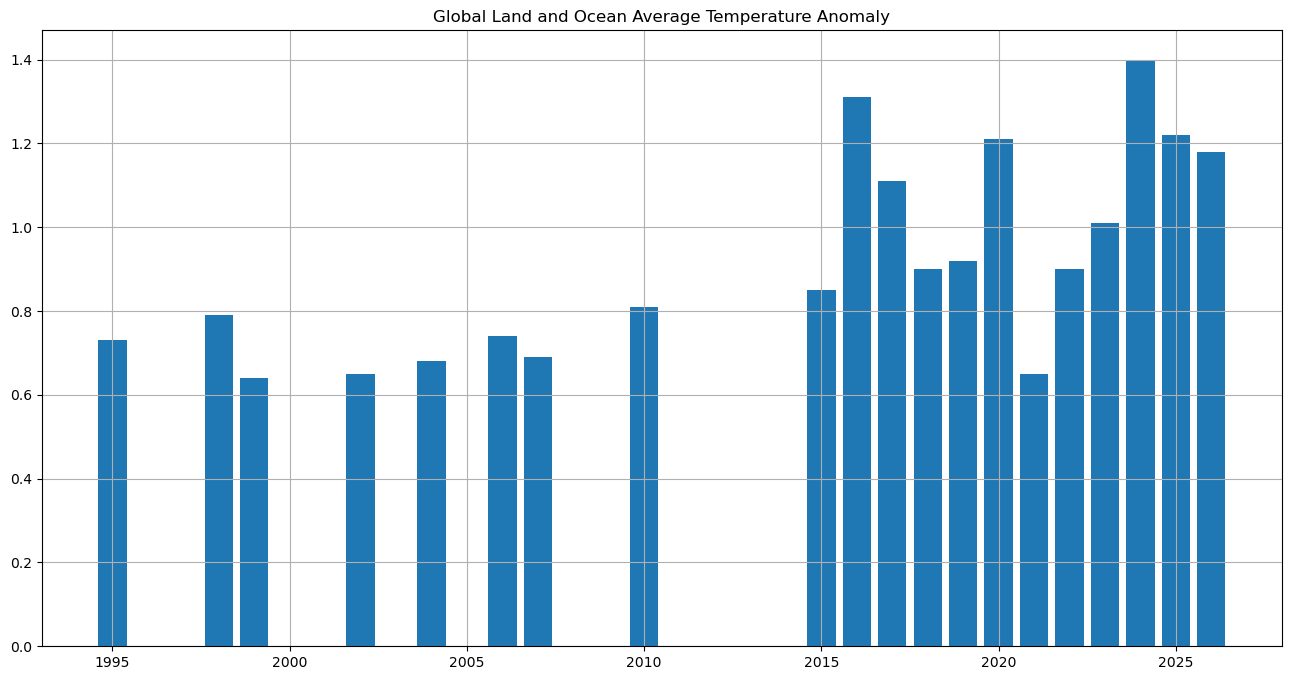

In [8]:
# Your code here:

DF_land_temp = DF.sort_values('-0.13',ascending=False).iloc[:20]
plt.figure(figsize=(16,8))
plt.title('Global Land and Ocean Average Temperature Anomaly')
x_values = DF_land_temp['1850']
y_values = DF_land_temp['-0.13']
plt.bar(x_values,y_values)
# plt.xticks(rotation=90)
plt.grid()

plt.show()

Go to the following webpage and consider the information:

https://en.wikipedia.org/wiki/2025_National_Women%27s_Soccer_League_season

If you are following the ethical principles of web scraping, should you scrape this data?


# YES

It is okay to scrape this data because it is publically available and there is not a clear way to download the data on the website. You should not scrape data that is only available to logged in paying users. You must make sure that you dont write code that access the website over and over - YOU SHOULD NOT SRAPE AT RATES THAT COULD DAMAGE THE WEBSITE.


# SO WHY DO WE GET THIS ERROR?

wikipedia blocks non-browser requests

## Sending headers

Many webistes now require that the user send header information to indentify themselves before allowing scraping. We need to do a few more things before we can get the information **DIFFERENT FOR 2026!**

In [14]:
# Import the requests package
# You might need !pip install requests
import requests

# Define the website
url = "https://en.wikipedia.org/wiki/2025_National_Women%27s_Soccer_League_season"
# Define a header - identifier
headers = {
    "User-Agent": "IntroDataScience WomensSoccer project"
}

# Request the html code with the header sent
resp = requests.get(url, headers=headers)
resp.raise_for_status()

# Now read the tables into pandas
tables = pd.read_html(resp.text)
print(len(tables))

# Example: first table
tables[0].head()

40


/var/folders/sp/r4p0vg7j5fx106g_l224vq6h0000gn/T/ipykernel_1512/2863130727.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(resp.text)


,0,1
0,Season,2025
1,Dates,March 14 – November 2 (regular season) Novembe...
2,Champions,Gotham FC (2nd title)
3,NWSL Shield,Kansas City Current (1st shield)
4,Challenge Cup,Washington Spirit (1st cup)


#### Practice 3

Write code that uses Pandas to get the data from the website:

https://www.localconditions.com/weather-redlands-california/92373/past.php


Look at the data contained in the data frame, can you figure out what is in there?

- How many data frames were returned - use the len() function.
- What is in each of those data frames? - You might want to write a for loop that goes through each data frame that was returned and display() the contents. 
- You will definitely need to go look at the webiste to see what each of the tables represents!

In [24]:
import requests

website = "https://www.localconditions.com/weather-redlands-california/92373/past.php"

DF = pd.read_html(
    requests.get(website, headers={"User-Agent": "Mozilla/5.0"}).text
)

DF[0].head()

# it kept saying HTTPError: HTTP Error 403: Forbidden when i did the regular format

/var/folders/sp/r4p0vg7j5fx106g_l224vq6h0000gn/T/ipykernel_1512/2562458525.py:5: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  DF = pd.read_html(


,Time,Temp. (ºF),Feel (ºF),Cloud Cover (%),Humidity (%),Dew Point (ºF),Barometer (inHg),Wind Speed (mph),Wind Direction,Wind Gust (mph),1hr. Precip / Rainfall (in),Snow Depth (in)
0,12 AM,63,63,0%,25%,25.9,29.98,3.1,NE,6.5,0,0
1,1 AM,62,62,0%,25%,25.3,29.98,2.9,NE,6.0,0,0
2,2 AM,60,60,0%,26%,24.8,29.98,3.4,NNE,6.9,0,0
3,3 AM,59,58,0%,27%,25.0,29.98,3.6,NNE,7.6,0,0
4,4 AM,58,57,0%,28%,25.0,29.98,3.1,NNE,6.5,0,0


In [21]:
len(DF)

31

In [26]:
for i in range(len(DF)):
    table = DF[i]
    print(f"DataFrame {i}:")
    display(table)

DataFrame 0:


,Time,Temp. (ºF),Feel (ºF),Cloud Cover (%),Humidity (%),Dew Point (ºF),Barometer (inHg),Wind Speed (mph),Wind Direction,Wind Gust (mph),1hr. Precip / Rainfall (in),Snow Depth (in)
0,12 AM,63,63,0%,25%,25.9,29.98,3.1,NE,6.5,0,0
1,1 AM,62,62,0%,25%,25.3,29.98,2.9,NE,6.0,0,0
2,2 AM,60,60,0%,26%,24.8,29.98,3.4,NNE,6.9,0,0
3,3 AM,59,58,0%,27%,25.0,29.98,3.6,NNE,7.6,0,0
4,4 AM,58,57,0%,28%,25.0,29.98,3.1,NNE,6.5,0,0
5,5 AM,60,59,0%,28%,25.0,29.98,3.6,NE,7.6,0,0
6,6 AM,63,62,0%,29%,30.4,29.99,4.3,NE,8.9,0,0
7,7 AM,66,65,0%,30%,33.1,29.99,4.3,NE,8.9,0,0
8,8 AM,73,72,0%,30%,35.8,29.99,3.8,NE,8.1,0,0
9,9 AM,79,77,0%,24%,38.8,29.98,1.8,N,2.0,0,0


DataFrame 1:


,Time,Temp. (ºF),Feel (ºF),Cloud Cover (%),Humidity (%),Dew Point (ºF),Barometer (inHg),Wind Speed (mph),Wind Direction,Wind Gust (mph),1hr. Precip / Rainfall (in),Snow Depth (in)
0,12 AM,66,66,0%,21%,24.6,30.03,2.9,NNE,6.0,0,0
1,1 AM,65,65,1%,22%,25.0,30.04,2.9,NNE,6.0,0,0
2,2 AM,64,64,1%,23%,25.3,30.04,2.9,NE,6.0,0,0
3,3 AM,63,63,0%,25%,26.6,30.04,3.6,NE,7.6,0,0
4,4 AM,62,62,0%,27%,27.3,30.05,3.6,NE,7.6,0,0
5,5 AM,62,62,0%,28%,27.9,30.05,3.8,NE,8.1,0,0
6,6 AM,63,63,0%,28%,28.6,30.06,3.8,NNE,8.1,0,0
7,7 AM,63,63,0%,28%,28.9,30.06,4.5,NNE,9.4,0,0
8,8 AM,69,69,0%,27%,29.3,30.06,4.0,NNE,8.5,0,0
9,9 AM,74,72,0%,21%,30.7,30.05,2.2,N,2.5,0,0


DataFrame 2:


...

,Time,Temp. (ºF),Feel (ºF),Cloud Cover (%),Humidity (%),Dew Point (ºF),Barometer (inHg),Wind Speed (mph),Wind Direction,Wind Gust (mph),1hr. Precip / Rainfall (in),Snow Depth (in)
0,12 AM,44,39,100%,98%,42.6,29.93,5.6,SSW,7.6,0.22,0
1,1 AM,45,41,100%,98%,44.1,29.93,6.3,SSW,9.2,0.25,0
2,2 AM,45,41,100%,98%,45.5,29.93,5.6,S,8.7,0.28,0
3,3 AM,46,41,100%,98%,45.1,29.94,4.7,S,7.8,0.24,0
4,4 AM,46,41,100%,98%,45.1,29.95,4.0,SW,6.9,0.23,0
5,5 AM,46,42,100%,98%,45.0,29.96,3.6,SSE,4.5,0.21,0
6,6 AM,46,42,100%,98%,45.5,29.98,3.6,SE,4.5,0.18,0
7,7 AM,46,42,100%,98%,45.7,29.98,3.6,SE,4.7,0.17,0
8,8 AM,47,42,100%,98%,46.0,29.99,4.3,SSE,5.6,0.15,0
9,9 AM,47,43,100%,98%,46.4,30.03,5.6,S,7.6,0.13,0


DataFrame 29:


,Time,Temp. (ºF),Feel (ºF),Cloud Cover (%),Humidity (%),Dew Point (ºF),Barometer (inHg),Wind Speed (mph),Wind Direction,Wind Gust (mph),1hr. Precip / Rainfall (in),Snow Depth (in)
0,12 AM,39,36,87%,75%,30.7,29.98,3.6,SE,6.7,0.00,0
1,1 AM,38,35,82%,78%,31.1,29.98,2.9,SSE,5.6,0.00,0
2,2 AM,37,34,76%,81%,31.3,29.98,3.6,SE,6.0,0.00,0
3,3 AM,36,34,88%,83%,31.1,29.96,3.8,SE,6.3,0.00,0
4,4 AM,36,33,94%,83%,30.9,29.96,3.4,SE,5.4,0.00,0
5,5 AM,35,34,100%,84%,30.7,29.94,4.5,SE,6.5,0.00,0
6,6 AM,35,34,100%,84%,30.9,29.94,5.4,SE,7.6,0.00,0
7,7 AM,36,34,100%,83%,30.9,29.94,5.6,SE,6.5,0.00,0
8,8 AM,39,37,100%,83%,30.9,29.93,6.0,ESE,6.9,0.00,0
9,9 AM,42,39,91%,85%,37.8,29.93,6.3,SE,7.2,0.00,0


DataFrame 30:


,0,1,2
0,NaN,74°F,30.07 inHg. Barometer 25% Humidity E 3.6 mph...
1,Sunny,Sunny,30.07 inHg. Barometer 25% Humidity E 3.6 mph...


#### Practice 4

Now you will do something with the data you found:

1. For each Data frame print out the column names? Are they all the Same?
2. For each Data Frame find out how many rows? Are they all the Same?
3. What is different about the last Data Frame? Where does Pandas get this data - look at the website.

In [28]:
for i in range(len(DF)):
    print(DF[i].keys())

Index(['Time', 'Temp. (ºF)', 'Feel (ºF)', 'Cloud Cover (%)', 'Humidity (%)',
       'Dew Point (ºF)', 'Barometer (inHg)', 'Wind Speed (mph)',
       'Wind Direction', 'Wind Gust (mph)', '1hr. Precip / Rainfall (in)',
       'Snow Depth (in)'],
      dtype='object')
Index(['Time', 'Temp. (ºF)', 'Feel (ºF)', 'Cloud Cover (%)', 'Humidity (%)',
       'Dew Point (ºF)', 'Barometer (inHg)', 'Wind Speed (mph)',
       'Wind Direction', 'Wind Gust (mph)', '1hr. Precip / Rainfall (in)',
       'Snow Depth (in)'],
      dtype='object')
Index(['Time', 'Temp. (ºF)', 'Feel (ºF)', 'Cloud Cover (%)', 'Humidity (%)',
       'Dew Point (ºF)', 'Barometer (inHg)', 'Wind Speed (mph)',
       'Wind Direction', 'Wind Gust (mph)', '1hr. Precip / Rainfall (in)',
       'Snow Depth (in)'],
      dtype='object')
Index(['Time', 'Temp. (ºF)', 'Feel (ºF)', 'Cloud Cover (%)', 'Humidity (%)',
       'Dew Point (ºF)', 'Barometer (inHg)', 'Wind Speed (mph)',
       'Wind Direction', 'Wind Gust (mph)', '1hr. Precip / R

In [30]:
same = all(list(DF[0].columns) == list(df.columns) for df in DF)
print(same)

False


In [31]:
for i in range(len(DF)):
    print(len(DF[i]))

24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
2


### scrolling to the bottom of the wesite past the dates, i think the last DF os the "past weather disclaimer"

In [34]:
same = all(len(DF[0]) == len(df) for df in DF)
print(same)

False


#### Practice 5

Choose one of the days (one data frame) and make a plot of all the information. You can use the .plot() function or use plt.plot() like you did above.

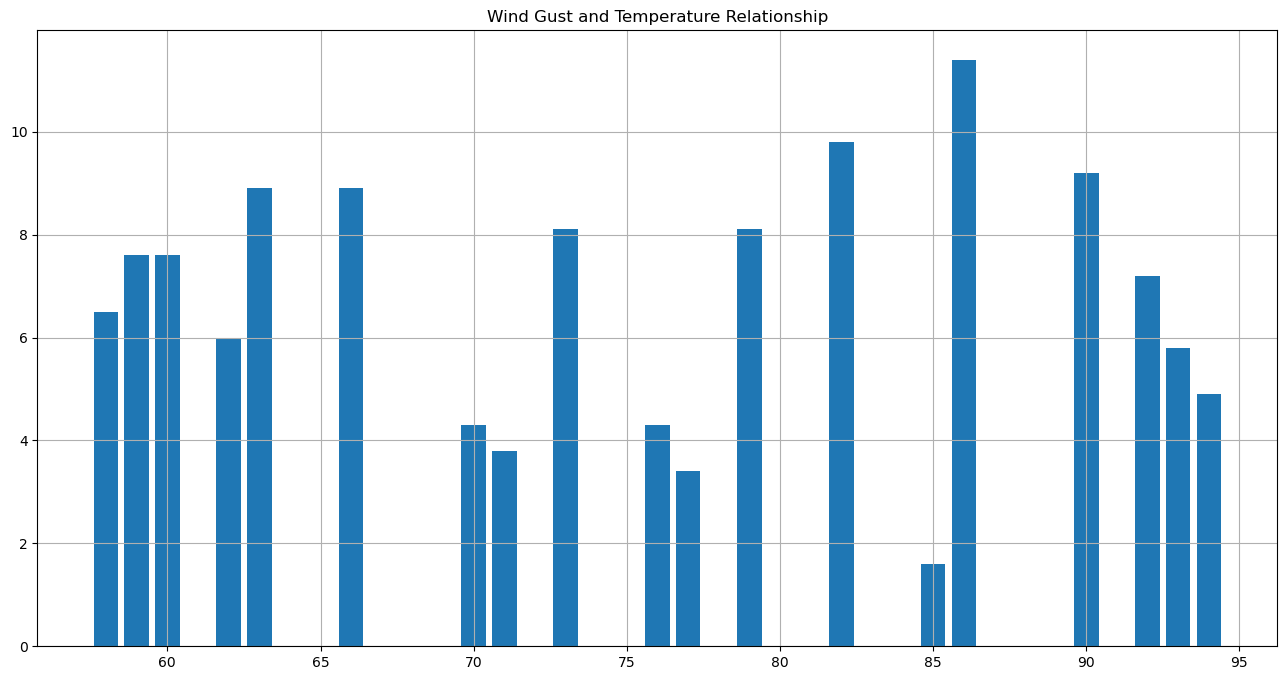

In [45]:
# Your code here:

DF_wind_cloud = DF[0].sort_values('Wind Gust (mph)',ascending=False)
plt.figure(figsize=(16,8))
plt.title('Wind Gust and Temperature Relationship')
x_values = DF_wind_cloud['Temp. (ºF)']
y_values = DF_wind_cloud['Wind Gust (mph)']
plt.bar(x_values,y_values)
plt.grid()

plt.show()

#### Practice 6

For each of the days in your set of data frames, find the average temperature and save it to a list. Then plot the average temperatere over time. REMEMBER you will need to loop through the data frames, BUT leave off the last one. This should be a slice of your list of data frames.

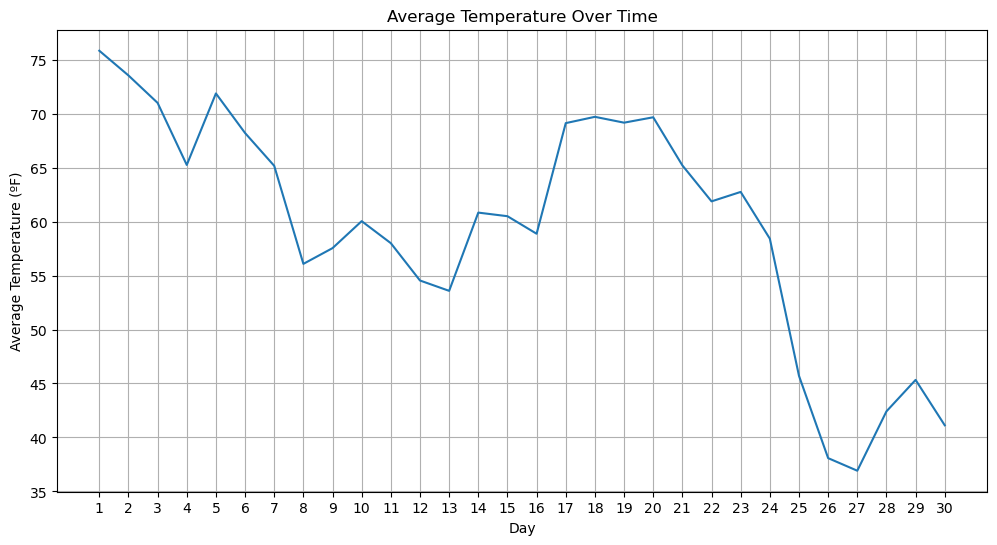

In [47]:
# Your code here

import matplotlib.pyplot as plt

dataframes = DF[:-1]

average_temps = [] 
days = []           

for i, df in enumerate(dataframes):
    avg_temp = df['Temp. (ºF)'].mean()
    average_temps.append(avg_temp)
    
    days.append(i + 1)

plt.figure(figsize=(12,6))
plt.plot(days, average_temps)
plt.title("Average Temperature Over Time")
plt.xlabel("Day")
plt.ylabel("Average Temperature (ºF)")
plt.xticks(days)  
plt.grid(True)
plt.show()

#### Practice 7 - Challenge

Find your own website that contains data in table format. Make sure it is ethical to scrape that data! Then use Pandas to get the information. BEWARE - you might get errors if it is a more complicated website - for example if it loads the data using scripts. It might take you a few tries to find data to scrape.

Then explore the data and see if you can make some plots or get some interesting information from the data.


In [53]:
# Your code here:

url = "https://www.ussoccer.com/uswnt-stats"
# Define a header - identifier
headers = {
    "User-Agent": "IntroDataScience WomensSoccer project"
}
resp = requests.get(url, headers=headers)
resp.raise_for_status()

# Now read the tables into pandas
tables = pd.read_html(resp.text)
print(len(tables))

# Example: first table
tables[0]
tables.keys()

2


/var/folders/sp/r4p0vg7j5fx106g_l224vq6h0000gn/T/ipykernel_1512/2073962643.py:12: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(resp.text)


AttributeError: 'list' object has no attribute 'keys'

In [51]:
# Your code here

DF_soccer = DF[0].sort_values('Goals',ascending=False)
plt.figure(figsize=(16,8))
plt.title('Wind Gust and Temperature Relationship')
x_values = DF_soccer['Pos.']
y_values = DF_soccer['Goals']
plt.bar(x_values,y_values)
plt.grid()

plt.show()

KeyError: 'Goals'